In [1]:
"""
This notebook is the base analysis and clearning of the dataset.
"""

'\nThis notebook is the base analysis and clearning of the dataset.\n'

In [2]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Reading the file

df_full = pd.read_csv('C:/Users/Kura/ddi/projects/launches/data/space_devs_launches_2010_2026.csv')

In [4]:
# Printing out the columns (there are WAY too many)

for col in df_full.columns:
    print(col)

id
url
name
response_mode
slug
launch_designator
last_updated
net
window_end
window_start
infographic
probability
weather_concerns
failreason
hashtag
mission
webcast_live
program
orbital_launch_attempt_count
location_launch_attempt_count
pad_launch_attempt_count
agency_launch_attempt_count
orbital_launch_attempt_count_year
location_launch_attempt_count_year
pad_launch_attempt_count_year
agency_launch_attempt_count_year
status.id
status.name
status.abbrev
status.description
net_precision.id
net_precision.name
net_precision.abbrev
net_precision.description
image.id
image.name
image.image_url
image.thumbnail_url
image.credit
image.license.id
image.license.name
image.license.priority
image.license.link
image.single_use
image.variants
launch_service_provider.response_mode
launch_service_provider.id
launch_service_provider.url
launch_service_provider.name
launch_service_provider.abbrev
launch_service_provider.type.id
launch_service_provider.type.name
rocket.id
rocket.configuration.response_m

In [5]:
# Shortening the dataset by specifying what columns to keep

cols_to_keep = ['id', 'name', 'launch_designator', 'net', 'window_end', 'window_start','failreason',
                'status.name', 'status.abbrev', 'launch_service_provider.name', 'launch_service_provider.type.name',
                'rocket.configuration.name', 'rocket.configuration.full_name', 'rocket.configuration.families',
                'mission.name', 'mission.type', 'mission.orbit.name', 'mission.orbit.abbrev', 'pad.name', 'pad.location.name',
                'pad.country.name', 'pad.latitude', 'pad.longitude']

df = df_full[cols_to_keep].copy()

In [6]:
# Renaming columns so they are easier to use

df = df.rename(columns={
    "id": "launch_id",
    "name": "launch_name",
    "launch_designator": "launch_designator",
    "net": "launch_datetime",
    "window_end": "launch_window_end",
    "window_start": "launch_window_start",
    "failreason": "failure_reason",

    "status.name": "status",
    "status.abbrev": "status_abbrev",

    "launch_service_provider.name": "launch_provider",
    "launch_service_provider.type.name": "provider_type",

    "rocket.configuration.name": "rocket_name",
    "rocket.configuration.full_name": "rocket_full_name",
    "rocket.configuration.families": "rocket_family",

    "mission.name": "mission_name",
    "mission.type": "mission_type",
    "mission.orbit.name": "orbit",
    "mission.orbit.abbrev": "orbit_abbrev",

    "pad.name": "launch_pad",
    "pad.location.name": "launch_location",
    "pad.country.name": "launch_country",
    "pad.latitude": "pad_latitude",
    "pad.longitude": "pad_longitude"
})

# Convert date columns to datetime
df['launch_datetime'] = pd.to_datetime(df['launch_datetime'], errors='coerce')
df['launch_window_start'] = pd.to_datetime(df['launch_window_start'], errors='coerce')
df['launch_window_end'] = pd.to_datetime(df['launch_window_end'], errors='coerce')

# Create useful time columns for analysis
df['year'] = df['launch_datetime'].dt.year
df['month'] = df['launch_datetime'].dt.month
df['quarter'] = df['launch_datetime'].dt.quarter

In [7]:
# Saving cleaned dataset
df.to_csv('C:/Users/Kura/ddi/projects/launches/data/space_devs_launches_cleaned.csv', index=False)

In [8]:
# Quick look at the cleaned dataset

df.head()

,launch_id,launch_name,launch_designator,launch_datetime,launch_window_end,launch_window_start,failure_reason,status,status_abbrev,launch_provider,...,orbit,orbit_abbrev,launch_pad,launch_location,launch_country,pad_latitude,pad_longitude,year,month,quarter
0,bb643566-508a-4f3a-a701-85669d11e2b3,Long March 3C | Compass-G1,2010-001,2010-01-16 16:12:04+00:00,2010-01-16 16:12:04+00:00,2010-01-16 16:12:04+00:00,NaN,Launch Successful,Success,China Aerospace Science and Technology Corpora...,...,NaN,NaN,Launch Complex 2 (LC-2),"Xichang Satellite Launch Center, People's Repu...",China,28.245504,102.026768,2010,1,1
1,470aff2b-3cc8-4e98-9ada-d511828b4676,Proton-M / Briz-M Enhanced | Globus-1M #12L (R...,2010-002,2010-01-28 00:18:00+00:00,2010-01-28 00:18:00+00:00,2010-01-28 00:18:00+00:00,NaN,Launch Successful,Success,Khrunichev State Research and Production Space...,...,NaN,NaN,81/24 (81P),"Baikonur Cosmodrome, Republic of Kazakhstan",Kazakhstan,46.071001,62.984999,2010,1,1
2,cb3977fe-3ef4-46d2-8bc9-65a0d9cef07a,Soyuz-U | Progress M-04M (36P),2010-003,2010-02-03 03:45:30+00:00,2010-02-03 03:45:30+00:00,2010-02-03 03:45:30+00:00,NaN,Launch Successful,Success,Russian Federal Space Agency (ROSCOSMOS),...,NaN,NaN,1/5,"Baikonur Cosmodrome, Republic of Kazakhstan",Kazakhstan,45.920000,63.342000,2010,2,1
3,80db2215-04bd-4d16-b998-311fb73db4fe,Space Shuttle Endeavour / OV-105 | STS-130,2010-004,2010-02-08 09:14:08+00:00,2010-02-08 09:14:08+00:00,2010-02-08 09:14:08+00:00,NaN,Launch Successful,Success,United Space Alliance,...,Low Earth Orbit,LEO,Launch Complex 39A,"Kennedy Space Center, FL, USA",United States of America,28.608227,-80.604282,2010,2,1
4,7e4160fc-c9d5-4db6-b9b1-166408741f0e,Atlas V 401 | SDO (Solar Dynamics Observatory),2010-005,2010-02-11 15:23:00+00:00,2010-02-11 15:23:00+00:00,2010-02-11 15:23:00+00:00,NaN,Launch Successful,Success,United Launch Alliance,...,Enhanced Geostationary Transfer Orbit,Enhanced-GTO,Space Launch Complex 41,"Cape Canaveral SFS, FL, USA",United States of America,28.583410,-80.583036,2010,2,1


In [9]:
# There are a LOT of null values in this dataset
# Many are to be expected, such as failure_reason but others may be dropped with if necessary in analysis

print(df.shape)
df.info()

# Dropped probability as that's probably only needed for weather analysis, and many null values

(2469, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2469 entries, 0 to 2468
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   launch_id            2469 non-null   object             
 1   launch_name          2469 non-null   object             
 2   launch_designator    2211 non-null   object             
 3   launch_datetime      2469 non-null   datetime64[ns, UTC]
 4   launch_window_end    2469 non-null   datetime64[ns, UTC]
 5   launch_window_start  2469 non-null   datetime64[ns, UTC]
 6   failure_reason       78 non-null     object             
 7   status               2469 non-null   object             
 8   status_abbrev        2469 non-null   object             
 9   launch_provider      2469 non-null   object             
 10  provider_type        2469 non-null   object             
 11  rocket_name          2469 non-null   object             
 12  rocket_fu

In [10]:
# Checking for duplicates

print(f"Full row duplicates: {df.duplicated().sum()}")
print(f"Launch id duplicates: {df['launch_id'].duplicated().sum()}")
print(f"Launch name duplicates: {df['launch_name'].duplicated().sum()}")

# Checks actual duplicates
# df[df["launch_name"].duplicated(keep=False)].sort_values("launch_name")

# Decided not to drop these rows as the IDs are distinct and are likely separate launch events

Full row duplicates: 0
Launch id duplicates: 0
Launch name duplicates: 20


In [11]:
df.sample(10)

,launch_id,launch_name,launch_designator,launch_datetime,launch_window_end,launch_window_start,failure_reason,status,status_abbrev,launch_provider,...,orbit,orbit_abbrev,launch_pad,launch_location,launch_country,pad_latitude,pad_longitude,year,month,quarter
333,d4b94e36-826f-4b19-abda-640794f86a51,PSLV XL | IRNSS-1B,2014-017,2014-04-04 11:44:00+00:00,2014-04-04 11:44:00+00:00,2014-04-04 11:44:00+00:00,NaN,Launch Successful,Success,Indian Space Research Organization,...,Geosynchronous Transfer Orbit,GSTO,Satish Dhawan Space Centre First Launch Pad,"Satish Dhawan Space Centre, India",India,13.733000,80.235000,2014,4,2
1925,0a8bf8c3-9f75-4fe9-a13d-9419eb09f432,Ceres-1S | Tianqi 16-18 & 20,2025-105,2025-05-19 07:38:00+00:00,2025-05-19 07:57:00+00:00,2025-05-19 07:29:00+00:00,NaN,Launch Successful,Success,Galactic Energy,...,Low Earth Orbit,LEO,Rizhao offshore launch location,Haiyang Oriental Spaceport,China,35.391667,119.598667,2025,5,2
477,43a4c987-39ad-4625-9ba0-59eda411617e,Long March 4B | Yaogan-28,2015-064,2015-11-08 07:06:04+00:00,2015-11-08 07:06:04+00:00,2015-11-08 07:06:04+00:00,NaN,Launch Successful,Success,China Aerospace Science and Technology Corpora...,...,NaN,NaN,Launch Complex 9,"Taiyuan Satellite Launch Center, People's Repu...",China,38.863128,111.589567,2015,11,4
807,f32feaf4-f28f-4c7d-a97f-ff31d75e6599,Long March 3B/E | Tianlian 2-01,2019-017,2019-03-31 15:51:04+00:00,2019-03-31 17:08:00+00:00,2019-03-31 15:44:00+00:00,NaN,Launch Successful,Success,China Aerospace Science and Technology Corpora...,...,Geostationary Transfer Orbit,GTO,Launch Complex 2 (LC-2),"Xichang Satellite Launch Center, People's Repu...",China,28.245504,102.026768,2019,3,1
2010,cad4ded9-6f24-4b6c-b4ed-b5dca4613cdd,Falcon 9 Block 5 | NAOS,2025-188,2025-08-26 18:53:41+00:00,2025-08-26 19:20:00+00:00,2025-08-26 18:53:00+00:00,NaN,Launch Successful,Success,SpaceX,...,Sun-Synchronous Orbit,SSO,Space Launch Complex 4E,"Vandenberg SFB, CA, USA",United States of America,34.632000,-120.611000,2025,8,3
2295,2bedbf8c-8df2-4e24-8397-8c2a08fab581,Long March 4B | Haiyang 2E,2026-149,2026-07-01 23:46:00+00:00,2026-07-02 00:07:00+00:00,2026-07-01 23:38:00+00:00,NaN,Launch Successful,Success,China Aerospace Science and Technology Corpora...,...,Sun-Synchronous Orbit,SSO,Launch Area 94 (SLS-2 / 603),"Jiuquan Satellite Launch Center, People's Repu...",China,40.960482,100.298059,2026,7,3
1228,ac4ce8e1-fd76-4654-8809-5500ba792a8a,Falcon 9 Block 5 | Starlink Group 4-21,2022-076,2022-07-07 13:11:00+00:00,2022-07-07 13:11:00+00:00,2022-07-07 13:11:00+00:00,NaN,Launch Successful,Success,SpaceX,...,Low Earth Orbit,LEO,Space Launch Complex 40,"Cape Canaveral SFS, FL, USA",United States of America,28.561941,-80.577357,2022,7,3
2308,a556b963-0f36-4660-95a8-fdffdba653e2,Soyuz 2.1a | Soyuz MS-29,NaN,2026-07-14 14:47:43+00:00,2026-07-14 14:47:43+00:00,2026-07-14 14:47:43+00:00,NaN,Go for Launch,Go,Russian Federal Space Agency (ROSCOSMOS),...,Low Earth Orbit,LEO,31/6,"Baikonur Cosmodrome, Republic of Kazakhstan",Kazakhstan,45.996034,63.564003,2026,7,3
2181,742daf86-0810-4df5-8a7d-1ff72a14e261,Falcon 9 Block 5 | Starlink Group 17-26,2026-038,2026-02-25 14:17:49+00:00,2026-02-25 18:00:00+00:00,2026-02-25 14:00:00+00:00,NaN,Launch Successful,Success,SpaceX,...,Low Earth Orbit,LEO,Space Launch Complex 4E,"Vandenberg SFB, CA, USA",United States of America,34.632000,-120.611000,2026,2,1
330,795cc32b-8a4f-47e4-9f4e-f3d3b24ddff5,Long March 2C | Shijian 11-06,2014-014,2014-03-31 02:46:03+00:00,2014-03-31 02:46:03+00:00,2014-03-31 02:46:03+00:00,NaN,Launch Successful,Success,China Aerospace Science and Technology Corpora...,...,NaN,NaN,Launch Area 94 (SLS-2 / 603),"Jiuquan Satellite Launch Center, People's Repu...",China,40.960482,100.298059,2014,3,1


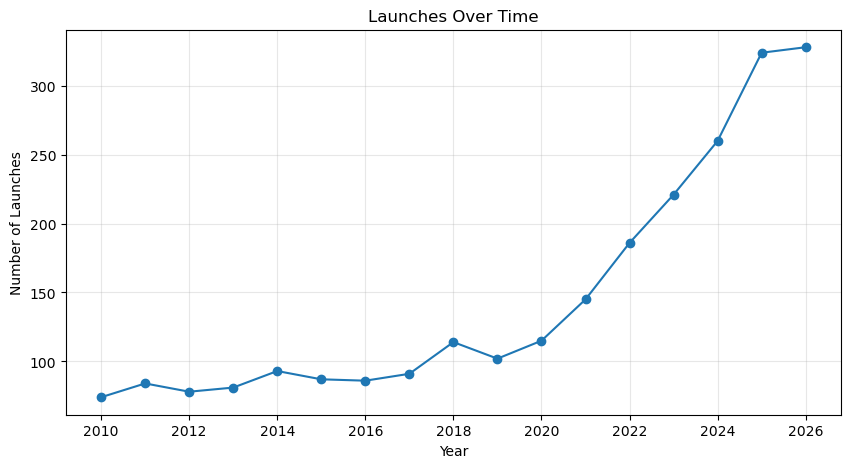

In [12]:
launches_by_year = df.groupby('year').size()

plt.figure(figsize=(10, 5))
plt.plot(launches_by_year.index, launches_by_year.values, marker="o")
plt.title("Launches Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Launches")
plt.grid(True, alpha=0.3)
plt.show()

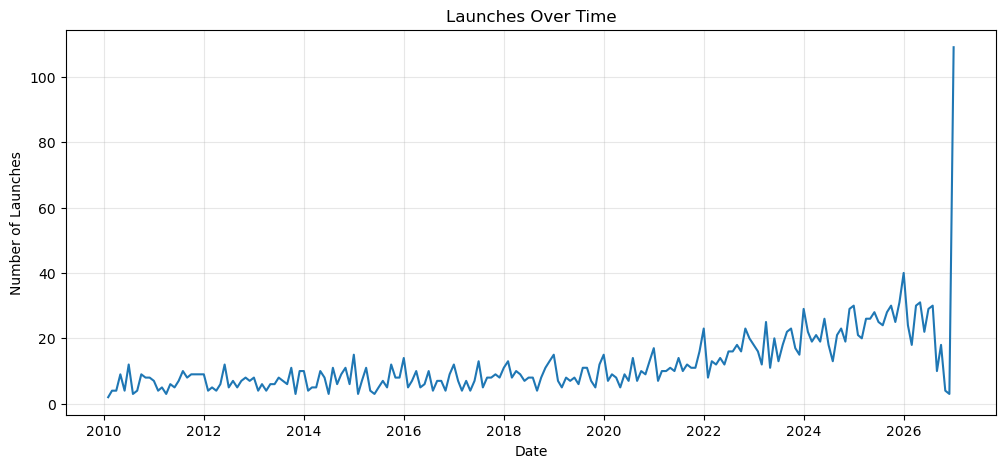

In [13]:
launches_by_month = (
    df.set_index('launch_datetime')
    .resample("ME")
    .size()
)

plt.figure(figsize=(12, 5))
plt.plot(launches_by_month.index, launches_by_month.values)
plt.title("Launches Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Launches")
plt.grid(True, alpha=0.3)
plt.show()

# That's really interesting?? Why does it spike so much in the end? Maybe confirm later with some other data for launches in 2026

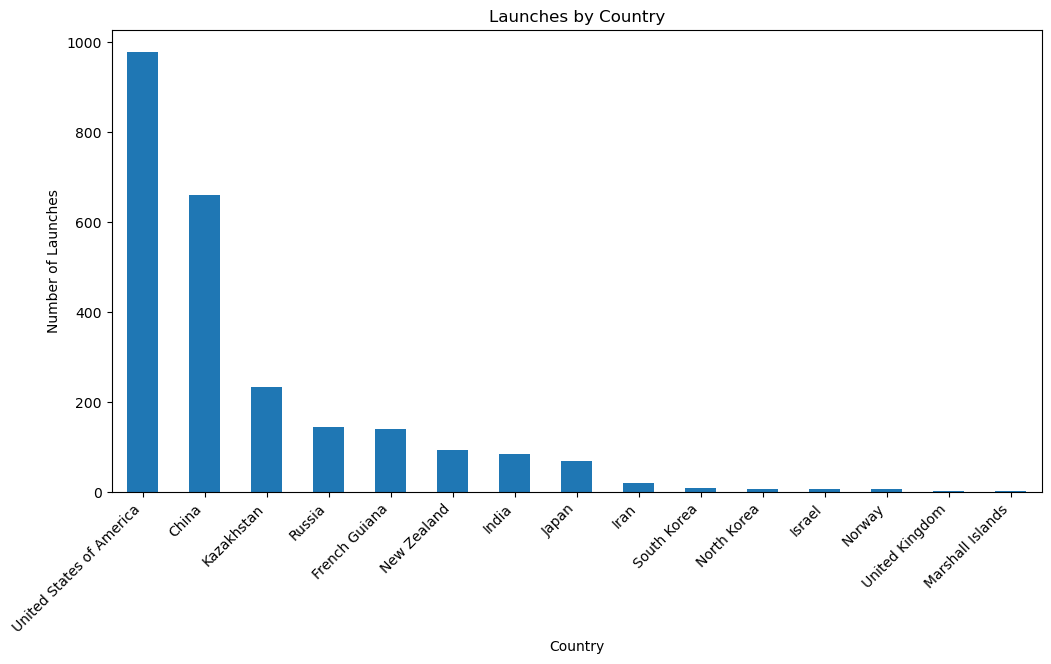

In [14]:
# Getting launches by country

launches_by_country = df.groupby('launch_country').size().sort_values(ascending=False)
top_countries = launches_by_country.head(15)

plt.figure(figsize=(12, 6))

top_countries.plot(kind='bar')

plt.title("Launches by Country")
plt.xlabel('Country')
plt.ylabel('Number of Launches')
plt.xticks(rotation=45, ha='right')
plt.show()

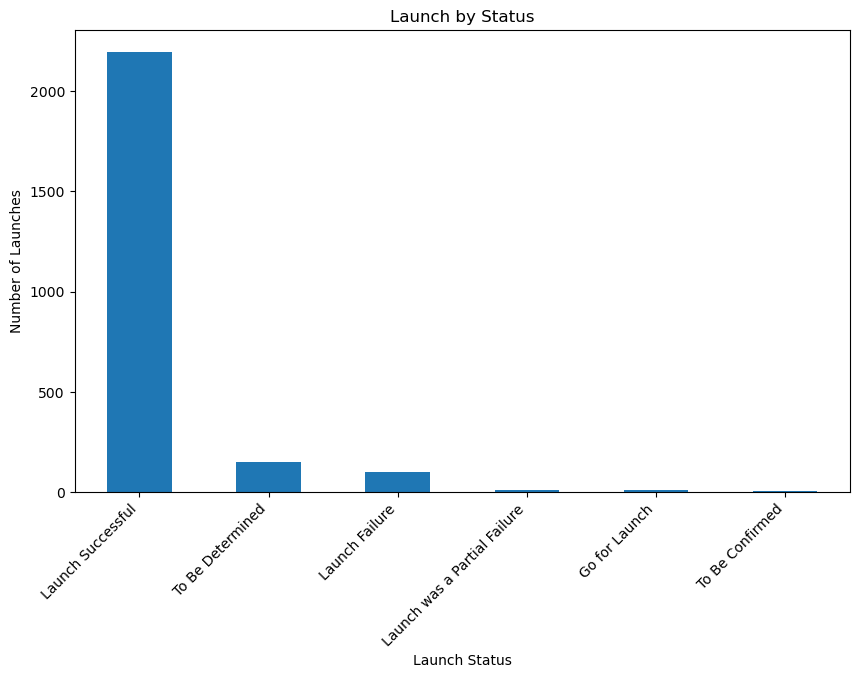

In [20]:
launch_status = df.groupby('status').size().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

launch_status.plot(kind='bar')

plt.title('Launch by Status')
plt.xlabel('Launch Status')
plt.ylabel('Number of Launches')
plt.xticks(rotation=45, ha='right')
plt.show()